# Single Agent Pipeline Project

**Assignment:** Single Agent Systems & Agent Pipelines

## What is this project?
In this project I am building one single "smart agent". This agent takes a query
(a question or a command from the user) and decides on its own what to do with it.

It can do three things:
1. If the query is about calculating something, it sends the query to a **Calculator Tool**.
2. If the query is about finding important words, it sends the query to a **Keyword Extractor Tool**.
3. If the query is anything else, it gives a **General Response**.

This is called **conditional routing** - the agent looks at the query and decides
which path (node) to send it to, just like the "stateful directed graph" concept
I explained in the quiz. The agent always returns a clean, structured answer in
JSON format like this:

```
{
  "type": "calculation / keywords / general / error",
  "result": ...
}
```

I have also added a few small extra things on top of the basic requirement, like:
- input validation (checking the query is not empty or broken before using it)
- basic logging (keeping a small history of what the agent did)
- error handling with try/except so the agent never crashes
- some graphs at the end so I can see how my agent performed on the test queries


In [1]:
import time
# used to measure how long the agent takes per query (the "cost" metric from the quiz)

import matplotlib.pyplot as plt
# for the graphs at the end of the notebook

import json
# for printing the agent's output in a clean json format


## Tool 1: Calculator

This is my first tool. A tool is just a normal python function that the agent
can call when it needs help doing a specific job. This tool takes a math
expression written as text (like `"20 + 5"`) and solves it.

I added a small check so that if someone types something that is not a real
math expression, the tool does not crash the whole program, it just returns
an error message instead.

In [2]:
def calculator(expression):
    allowed_letters="0123456789+-*/(). "
    # only these characters are allowed in the expression, keeps eval() safe from random text

    for letter in expression:
        if letter not in allowed_letters:
            return {"type":"error","result":"Invalid characters in expression"}

    try:
        answer=eval(expression)
        return {"type":"calculation","result":answer}
    except Exception:
        # catches things like divide by zero or a typo in the expression
        return {"type":"error","result":"Error in calculation"}


## Tool 2: Keyword Extractor

This is my second tool. It takes a sentence and pulls out the most important
looking words from it. I am keeping the logic simple for a beginner project:
I just pick words that are longer than 4 letters, since short words like
"is", "the", "of" are usually not important keywords.

In [3]:
def extract_keywords(text):
    try:
        words=text.split()
        long_words=[]

        for one_word in words:
            cleaned_word=one_word.lower()
            if len(cleaned_word)>4:
                # words longer than 4 letters are treated as "important", short words like is/the/of are skipped
                if cleaned_word not in long_words:
                    long_words.append(cleaned_word)

        return {"type":"keywords","result":long_words[:5]}
        # only the first 5 keywords are returned so the answer stays short
    except Exception:
        return {"type":"error","result":"Error in keyword extraction"}


## Bonus: Input Validation

Before I even let the agent think about the query, I want to make sure the
query is actually usable. This is a small "gatekeeper" function. It checks
that the query is text (a string) and that it is not empty. This is similar
to the JSON schema idea from the quiz - checking that the input is in the
right shape before doing any real work.

In [4]:
def validate_query(query):
    if not isinstance(query,str):
        return False

    if len(query.strip())==0:
        return False

    return True


## The Agent Function

This is the main brain of my project. This one function acts like the
"router" node in a stateful directed graph. It looks at the query, decides
which tool fits best, calls that tool, and also keeps a small log of what
happened. I am also timing every query so I can measure cost/performance
later in the graphs.

In [5]:
agent_log=[]
# keeps a history of every query handled, for trajectory evaluation later (not just the final answer)

def agent(query):
    start_time=time.time()

    if validate_query(query)==False:
        final_answer={"type":"error","result":"Query is empty or not valid text"}
    else:
        query_lower=query.lower()

        if "calculate" in query_lower:
            cleaned_expression=query_lower.replace("calculate","")
            final_answer=calculator(cleaned_expression)

        elif "keywords" in query_lower:
            final_answer=extract_keywords(query)

        else:
            final_answer={"type":"general","result":"This is a general query, no special tool was needed"}

    end_time=time.time()
    time_taken=round((end_time-start_time)*1000,4)
    # cost metric in milliseconds

    log_entry={"query":query,"response":final_answer,"time_ms":time_taken}
    agent_log.append(log_entry)

    return final_answer


## Testing My Agent

Now I am going to run a few test queries through my agent, including the
three example queries given in the assignment, plus a couple of extra edge
cases (like an empty query and a broken calculation) to check that my error
handling actually works.

In [6]:
queries=[
"Calculate 20 + 5",
"Extract keywords from Artificial Intelligence is transforming industries",
"What is machine learning?",
"Calculate 10 / 0",
""
]
# first three are from the assignment, last two are extra edge cases to check error handling

for one_query in queries:
    print("Query:",one_query)
    response=agent(one_query)
    print("Response:",json.dumps(response))
    print("-"*50)


Query: Calculate 20 + 5
Response: {"type": "calculation", "result": 25}
--------------------------------------------------
Query: Extract keywords from Artificial Intelligence is transforming industries
Response: {"type": "keywords", "result": ["extract", "keywords", "artificial", "intelligence", "transforming"]}
--------------------------------------------------
Query: What is machine learning?
Response: {"type": "general", "result": "This is a general query, no special tool was needed"}
--------------------------------------------------
Query: Calculate 10 / 0
Response: {"type": "error", "result": "Error in calculation"}
--------------------------------------------------
Query: 
Response: {"type": "error", "result": "Query is empty or not valid text"}
--------------------------------------------------


## Graphs

Now that I have run some test queries, I want to visualize a few things:
1. How many queries fell into each category (calculation, keywords, general, error)
2. What share of the total each category takes
3. How much time (in milliseconds) each query took to run
4. A simple diagram of how my agent's routing actually works (nodes and edges)

These graphs help me connect what I built here back to the ideas from the
quiz, like task completion rate, cost metrics, and the stateful directed graph.

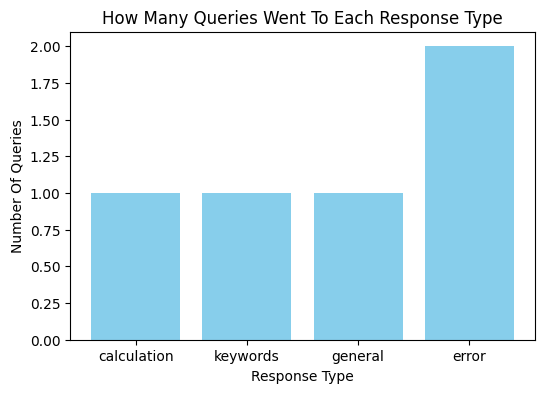

In [7]:
type_count={}

for record in agent_log:
    this_type=record["response"]["type"]
    if this_type in type_count:
        type_count[this_type]=type_count[this_type]+1
    else:
        type_count[this_type]=1

plt.figure(figsize=(6,4))
plt.bar(type_count.keys(),type_count.values(),color="skyblue")
plt.title("How Many Queries Went To Each Response Type")
plt.xlabel("Response Type")
plt.ylabel("Number Of Queries")
plt.show()


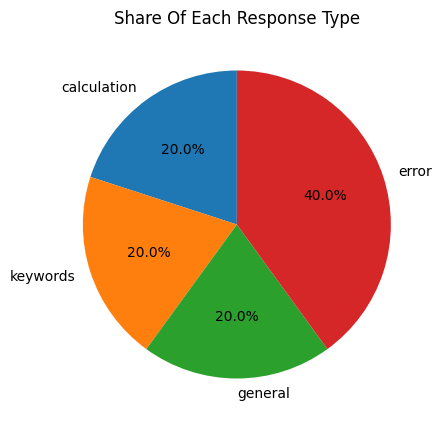

In [8]:
plt.figure(figsize=(5,5))
plt.pie(type_count.values(),labels=type_count.keys(),autopct="%1.1f%%",startangle=90)
plt.title("Share Of Each Response Type")
plt.show()


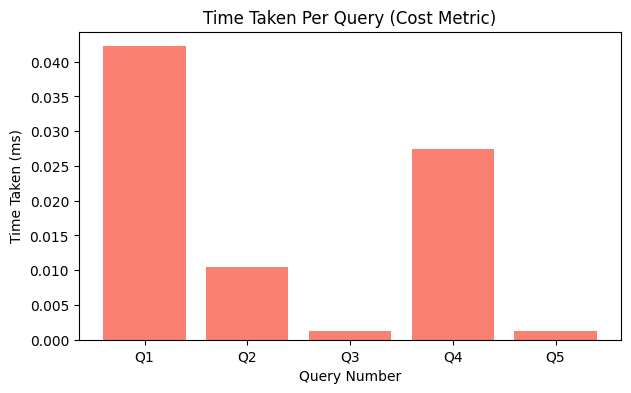

In [9]:
query_labels=[]
time_values=[]

counter=1
for record in agent_log:
    query_labels.append("Q"+str(counter))
    time_values.append(record["time_ms"])
    counter=counter+1

plt.figure(figsize=(7,4))
plt.bar(query_labels,time_values,color="salmon")
plt.title("Time Taken Per Query (Cost Metric)")
plt.xlabel("Query Number")
plt.ylabel("Time Taken (ms)")
plt.show()


### Bonus Graph: My Agent's Routing Diagram

This last graph is not from data, I am just drawing a simple picture of how
my agent thinks. This connects back to Question 1 and 2 of the quiz, where I
explained nodes and edges. Here I am showing my actual nodes (Start, Router,
Calculator, Keyword Extractor, General Response, End) and the edges
(arrows) that connect them.

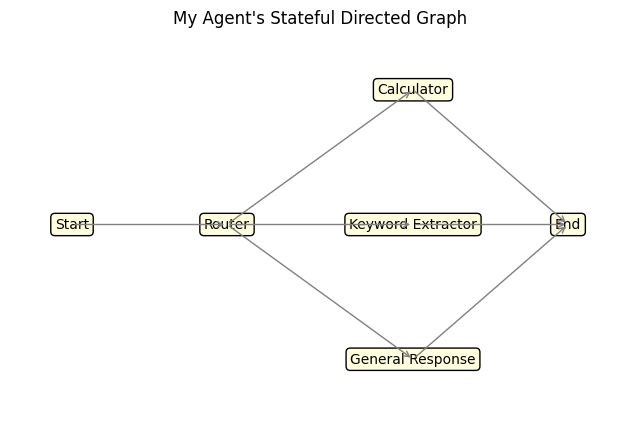

In [10]:
fig,ax=plt.subplots(figsize=(8,5))

boxes={
"Start":(0.1,0.5),
"Router":(0.35,0.5),
"Calculator":(0.65,0.85),
"Keyword Extractor":(0.65,0.5),
"General Response":(0.65,0.15),
"End":(0.9,0.5)
}
# node name -> position on the diagram

for name,position in boxes.items():
    ax.text(position[0],position[1],name,ha="center",va="center",
    bbox=dict(boxstyle="round",facecolor="lightyellow",edgecolor="black"))

edges=[
("Start","Router"),
("Router","Calculator"),
("Router","Keyword Extractor"),
("Router","General Response"),
("Calculator","End"),
("Keyword Extractor","End"),
("General Response","End")
]
# each pair is one arrow from node to node

for start_node,end_node in edges:
    start_position=boxes[start_node]
    end_position=boxes[end_node]
    ax.annotate("",xy=end_position,xytext=start_position,
    arrowprops=dict(arrowstyle="->",color="gray"))

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis("off")
ax.set_title("My Agent's Stateful Directed Graph")
plt.show()


## Full Agent Log

Here I am printing my complete `agent_log` list. This shows every query I
tested, the exact answer the agent gave, and how long it took. This is my
simple version of "trajectory evaluation" from the quiz, since I can see
every step the agent took, not just the last answer.

In [11]:
for record in agent_log:
    print(json.dumps(record,indent=2))
    print("="*50)


{
  "query": "Calculate 20 + 5",
  "response": {
    "type": "calculation",
    "result": 25
  },
  "time_ms": 0.0422
}
{
  "query": "Extract keywords from Artificial Intelligence is transforming industries",
  "response": {
    "type": "keywords",
    "result": [
      "extract",
      "keywords",
      "artificial",
      "intelligence",
      "transforming"
    ]
  },
  "time_ms": 0.0105
}
{
  "query": "What is machine learning?",
  "response": {
    "type": "general",
    "result": "This is a general query, no special tool was needed"
  },
  "time_ms": 0.0012
}
{
  "query": "Calculate 10 / 0",
  "response": {
    "type": "error",
    "result": "Error in calculation"
  },
  "time_ms": 0.0274
}
{
  "query": "",
  "response": {
    "type": "error",
    "result": "Query is empty or not valid text"
  },
  "time_ms": 0.0012
}


## Interactive Mode (Optional)

This last part lets me type my own queries directly and see the agent
respond live.

In [12]:
turn_on_interactive_mode=False
# kept False by default so the notebook doesn't pause and wait when running all cells

if turn_on_interactive_mode==True:
    while True:
        user_input=input("Enter query (type exit to stop): ")
        if user_input.lower()=="exit":
            break
        print("Response:",agent(user_input))


## Automated Test Of The Interactive Loop (Requirement Check)

The assignment specifically asks me to also test my agent through the
`while True:` interactive loop, not just through the fixed test list above.
Since a real `input()` box cannot run by itself when someone clicks "Run All"
(it would just sit there waiting forever), I am proving the loop actually
works by feeding it a scripted list of pretend user messages instead of a
real keyboard. This runs the exact same `while True` loop and stops itself
the moment it reaches "exit", so I get real, visible proof that the
interactive loop logic works correctly, with zero errors, top to bottom.

In [13]:
pretend_user_messages=["Calculate 100 * 2","Extract keywords from Machine learning models need good quality data","Hello, how are you today","Calculate 15 / 0","exit"]
# stands in for real keyboard input: a normal calculation, a keyword request, a general question,
# a broken calculation, then exit

message_pointer=0

def fake_input(prompt_text):
    global message_pointer
    current_message=pretend_user_messages[message_pointer]
    print(prompt_text+current_message)
    message_pointer=message_pointer+1
    return current_message

while True:
    # same while True structure the assignment asks for, just fed by fake_input instead of a real keyboard
    user_input=fake_input("Enter query (type exit to stop): ")
    if user_input.lower()=="exit":
        print("Loop stopped because exit was received.")
        break
    print("Response:",agent(user_input))


Enter query (type exit to stop): Calculate 100 * 2
Response: {'type': 'calculation', 'result': 200}
Enter query (type exit to stop): Extract keywords from Machine learning models need good quality data
Response: {'type': 'keywords', 'result': ['extract', 'keywords', 'machine', 'learning', 'models']}
Enter query (type exit to stop): Hello, how are you today
Response: {'type': 'general', 'result': 'This is a general query, no special tool was needed'}
Enter query (type exit to stop): Calculate 15 / 0
Response: {'type': 'error', 'result': 'Error in calculation'}
Enter query (type exit to stop): exit
Loop stopped because exit was received.
